1. Load and Inspect the Dataset

In [1]:
import pandas as pd

# Load dataset
df = pd.read_parquet("plant_pictures.parquet")

# Basic information
print("Dataset shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nLabel distribution:")
print(df['label'].value_counts())

Dataset shape:
(6127, 4)

Columns:
Index(['image', 'mask', 'crop_type', 'label'], dtype='object')

Label distribution:
label
healthy     3798
stressed    2329
Name: count, dtype: int64


2. Decode and Visualize an Image

Image type: <class 'PIL.JpegImagePlugin.JpegImageFile'>
Image size: (120, 120)
Image mode: RGB


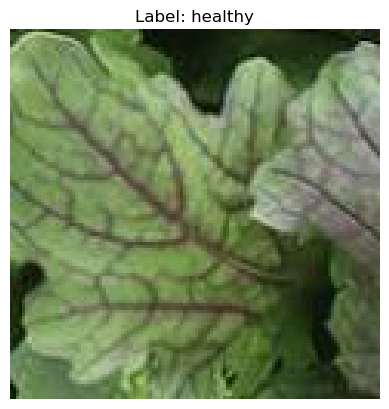

In [2]:
from PIL import Image
import io
import matplotlib.pyplot as plt

# Extract first image bytes
img_bytes = df.iloc[0]['image']['bytes']

# Convert bytes to image
img = Image.open(io.BytesIO(img_bytes))

# Print image information
print("Image type:", type(img))
print("Image size:", img.size)
print("Image mode:", img.mode)

# Display image
plt.imshow(img)
plt.title(f"Label: {df.iloc[0]['label']}")
plt.axis('off')
plt.show()

3. Preprocess Images for CNN

In [3]:
import numpy as np
from PIL import Image
import io

# Lists
images = []
labels = []

IMG_SIZE = 120

for _, row in df.iterrows():

    # Extract image bytes
    img_bytes = row['image']['bytes']

    # Open image
    img = Image.open(io.BytesIO(img_bytes)).convert('RGB')

    # Resize image
    img = img.resize((IMG_SIZE, IMG_SIZE))

    # Convert to array
    img_array = np.array(img)

    # Normalize pixel values
    img_array = img_array / 255.0

    # Keep 2D image structure for CNN
    images.append(img_array)

    # Store labels
    labels.append(row['label'])

# Convert lists to arrays
X = np.array(images)
y = np.array(labels)

# Check shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nExample image shape:")
print(X[0].shape)

print("\nFirst 10 labels:")
print(y[:10])

X shape: (6127, 120, 120, 3)
y shape: (6127,)

Example image shape:
(120, 120, 3)

First 10 labels:
['healthy' 'stressed' 'stressed' 'stressed' 'stressed' 'healthy' 'healthy'
 'stressed' 'healthy' 'healthy']


4. Encode Labels

In [4]:
from sklearn.preprocessing import LabelEncoder

# Encode labels
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

# Check mapping
print("Classes:")
print(encoder.classes_)

print("\nFirst 10 encoded labels:")
print(y_encoded)

Classes:
['healthy' 'stressed']

First 10 encoded labels:
[0 1 1 ... 1 0 1]
